# Dependências

In [ ]:
import os
import zipfile

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from imblearn.over_sampling import SMOTE

# Carregamento dos Dados

In [18]:
DATA_DIR = "../data"
ZIP_NAME = "ocorrencias_aviacao_civil_br.zip"
EXTRACT_DIR = "ocorrencias_aviacao_civil_br"
CSV_NAME = "ocorrencias_aviacao_civil_br.csv"

ZIP_PATH = os.path.join(DATA_DIR, ZIP_NAME)
CSV_PATH = os.path.join(DATA_DIR, EXTRACT_DIR, CSV_NAME)

if not os.path.exists(ZIP_PATH):
    raise FileNotFoundError(f"Dataset not found at '{ZIP_PATH}'. Place the zip file there and rerun.")

if not os.path.exists(CSV_PATH):
    with zipfile.ZipFile(ZIP_PATH, 'r') as zip_ref:
        zip_ref.extractall(DATA_DIR)

df = pd.read_csv(CSV_PATH)


# Análise Exploratória Inicial

In [19]:
df.head()

,codigo_ocorrencia,ocorrencia_classificacao,ocorrencia_tipo,ocorrencia_tipo_categoria,ocorrencia_tipo_icao,ocorrencia_latitude,ocorrencia_longitude,ocorrencia_cidade,ocorrencia_uf,ocorrencia_pais,...,ocorrencia_horario,investigacao_aeronave_liberada,investigacao_status,divulgacao_relatorio_numero,divulgacao_relatorio_publicado,divulgacao_dia_publicacao,total_recomendacoes,total_aeronaves_envolvidas,ocorrencia_saida_pista,ocorrencia_dia_extracao
0,201305055424986,ACIDENTE,FALHA DO MOTOR EM VOO,FALHA OU MAU FUNCIONAMENTO DO MOTOR,SCF-PP,-9.9085,-63.0333,ARIQUEMES,RO,BRASIL,...,11:00:00,NaN,FINALIZADA,***,NÃO,NaN,0,1,NÃO,2018-08-28
1,201605160250139,INCIDENTE GRAVE,COLISÃO COM OBSTÁCULO DURANTE A DECOLAGEM E POUSO,COLISÃO COM OBSTÁCULO DURANTE A DECOLAGEM E POUSO,CTOL,-11.2644,-61.2589,CACOAL,RO,BRASIL,...,19:19:00,SIM,ATIVA,IG-084/CENIPA/2016,NÃO,NaN,0,1,NÃO,2018-08-28
2,201805021421302,INCIDENTE,AERÓDROMO,AERÓDROMO,ADRM,-11.4956,-61.4508,CACOAL,RO,BRASIL,...,22:40:00,SIM,FINALIZADA,***,NÃO,NaN,0,1,NÃO,2018-08-28
3,201311259977425,INCIDENTE GRAVE,POUSO SEM TREM,CONTATO ANORMAL COM A PISTA,ARC,-11.4956,-61.4508,CACOAL,RO,BRASIL,...,12:32:00,NaN,FINALIZADA,IG-209/CENIPA/2013,SIM,2014-04-07,0,1,NÃO,2018-08-28
4,201103187273112,INCIDENTE,OUTROS,OUTROS,OTHR,-13.1950,-60.8184,CEREJEIRAS,RO,BRASIL,...,13:30:00,NaN,FINALIZADA,***,NÃO,NaN,0,1,NÃO,2018-08-28


In [20]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5208 entries, 0 to 5207
Data columns (total 22 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   codigo_ocorrencia               5208 non-null   int64  
 1   ocorrencia_classificacao        5208 non-null   str    
 2   ocorrencia_tipo                 5208 non-null   str    
 3   ocorrencia_tipo_categoria       5208 non-null   str    
 4   ocorrencia_tipo_icao            5208 non-null   str    
 5   ocorrencia_latitude             5208 non-null   float64
 6   ocorrencia_longitude            5208 non-null   float64
 7   ocorrencia_cidade               5208 non-null   str    
 8   ocorrencia_uf                   5208 non-null   str    
 9   ocorrencia_pais                 5208 non-null   str    
 10  ocorrencia_aerodromo            5208 non-null   str    
 11  ocorrencia_dia                  5208 non-null   str    
 12  ocorrencia_horario              5208 non-null

In [21]:
print("Verificando valores nulos no DataFrame:")
print(df.isnull().sum())

Verificando valores nulos no DataFrame:
codigo_ocorrencia                    0
ocorrencia_classificacao             0
ocorrencia_tipo                      0
ocorrencia_tipo_categoria            0
ocorrencia_tipo_icao                 0
ocorrencia_latitude                  0
ocorrencia_longitude                 0
ocorrencia_cidade                    0
ocorrencia_uf                        0
ocorrencia_pais                      0
ocorrencia_aerodromo                 0
ocorrencia_dia                       0
ocorrencia_horario                   0
investigacao_aeronave_liberada    4098
investigacao_status                  0
divulgacao_relatorio_numero          0
divulgacao_relatorio_publicado       0
divulgacao_dia_publicacao         3947
total_recomendacoes                  0
total_aeronaves_envolvidas           0
ocorrencia_saida_pista               0
ocorrencia_dia_extracao              0
dtype: int64


In [22]:
print("Valores únicos em 'ocorrencia_tipo_categoria':")
print(df['ocorrencia_tipo_categoria'].unique())

Valores únicos em 'ocorrencia_tipo_categoria':
<StringArray>
[                'FALHA OU MAU FUNCIONAMENTO DO MOTOR',
   'COLISÃO COM OBSTÁCULO DURANTE A DECOLAGEM E POUSO',
                                           'AERÓDROMO',
                         'CONTATO ANORMAL COM A PISTA',
                                              'OUTROS',
                           'PERDA DE CONTROLE NO SOLO',
                                   'EXCURSÃO DE PISTA',
                 'PERDA DE SEPARAÇÃO / COLISÃO EM VOO',
                            'PERDA DE CONTROLE EM VOO',
  'FALHA OU MAU FUNCIONAMENTO DE SISTEMA / COMPONENTE',
                                       'INDETERMINADO',
                     'VOO CONTROLADO CONTRA O TERRENO',
                                   'INCURSÃO EM PISTA',
 'FALHA OU MAU FUNCIONAMENTO DE SISTEMA / COMPONENTE ',
                           'POUSO AQUÉM/ALÉM DA PISTA',
                                              'MÉDICO',
                                     'COLIS

### Decisões baseadas na análise exploratória

#### Valores nulos
As únicas colunas com valores nulos são `investigacao_aeronave_liberada` (4.098 nulos) 
e `divulgacao_dia_publicacao` (3.947 nulos). Ambas serão descartadas, não por causa 
dos nulos em si, mas porque não têm valor preditivo para o objetivo do modelo.

#### Colunas descartadas
| Coluna | Motivo |
|---|---|
| `codigo_ocorrencia` | Identificador único, sem valor preditivo |
| `ocorrencia_tipo` | Risco de data leakage — descreve o mesmo evento que o target |
| `ocorrencia_tipo_icao` | Risco de data leakage — codificação do tipo de ocorrência |
| `ocorrencia_latitude` | Localização geográfica sem relação causal com o target |
| `ocorrencia_longitude` | Localização geográfica sem relação causal com o target |
| `ocorrencia_cidade` | Alta cardinalidade, substituída por `uf` |
| `ocorrencia_pais` | Coluna constante — todos os registros são `BRASIL` |
| `ocorrencia_aerodromo` | Alta cardinalidade, sem relação causal com o target |
| `investigacao_aeronave_liberada` | 4.098 nulos — descartada |
| `investigacao_status` | Dado posterior ao evento — status administrativo da investigação, não disponível no momento da ocorrência |
| `divulgacao_relatorio_numero` | Dado administrativo, sem valor preditivo |
| `divulgacao_relatorio_publicado` | Dado administrativo, sem valor preditivo |
| `divulgacao_dia_publicacao` | 3.947 nulos e posterior ao evento — descartada |
| `ocorrencia_dia_extracao` | Metadado do dataset, sem valor preditivo |
| `total_recomendacoes` | Descartada — dado posterior ao evento, gerado durante a investigação |

#### Colunas mantidas e transformações previstas
| Coluna original | Coluna resultante | Transformação |
|---|---|---|
| `ocorrencia_classificacao` | `classificacao` | Renomear + OneHotEncoder |
| `ocorrencia_uf` | `uf` | Renomear + OneHotEncoder |
| `ocorrencia_dia` | `mes_sin`, `mes_cos` | Extrair mês, aplicar codificação cíclica (seno e cosseno) e descartar original |
| `ocorrencia_horario` | `periodo_dia` | Mapear hora para Madrugada / Manhã / Tarde / Noite, descartar original e aplicar OneHotEncoder |
| `total_aeronaves_envolvidas` | `total_aeronaves` | Renomear |
| `ocorrencia_saida_pista` | `saida_pista` | Renomear + converter SIM/NÃO para 1/0 |
| `ocorrencia_tipo_categoria` | `fator_predominante` | Usada para criar o target e depois descartada |

#### Criação do target: `fator_predominante`
A coluna `ocorrencia_tipo_categoria` será usada para derivar o target do modelo. 
A classificação foi definida da seguinte forma:

**Humano:**
`PERDA DE CONTROLE EM VOO`, `PERDA DE CONTROLE NO SOLO`, `MANOBRA ABRUPTA`, 
`OPERAÇÃO A BAIXA ALTITUDE`, `MÉDICO`

**Técnico:**
`FALHA OU MAU FUNCIONAMENTO DO MOTOR`, 
`FALHA OU MAU FUNCIONAMENTO DE SISTEMA / COMPONENTE`, 
`FOGO/FUMAÇA (SEM IMPACTO)`

**Outros (excluídos do treinamento):**
`COLISÃO COM OBSTÁCULO DURANTE A DECOLAGEM E POUSO`, `AERÓDROMO`,
`CONTATO ANORMAL COM A PISTA`, `OUTROS`, `EXCURSÃO DE PISTA`,
`PERDA DE SEPARAÇÃO / COLISÃO EM VOO`, `INDETERMINADO`,
`VOO CONTROLADO CONTRA O TERRENO`, `INCURSÃO EM PISTA`,
`POUSO AQUÉM/ALÉM DA PISTA`, `COLISÃO NO SOLO`, `COMBUSTÍVEL`,
`TURBULÊNCIA`, `CORTANTE DE VENTO / TEMPESTADE`, `OPERAÇÕES NO SOLO`,
`RELACIONADO COM SECURITY`

Todas as categorias acima foram classificadas como `Outros` por serem ambíguas 
ou por não determinarem claramente uma causa humana ou técnica com base nos 
dados disponíveis. Essas linhas serão excluídas do treinamento.

Nota: foi identificada presença de espaços em branco no final de alguns valores de 
`ocorrencia_tipo_categoria` (ex: `FALHA OU MAU FUNCIONAMENTO DE SISTEMA / COMPONENTE `
e `CONTATO ANORMAL COM A PISTA `). Um `.strip()` será aplicado antes da classificação 
para garantir que esses casos sejam corretamente categorizados.

#### Tipos de dados
| Coluna | Tipo atual | Tipo esperado | Ação |
|---|---|---|---|
| `ocorrencia_classificacao` | `str` | `int` | OneHotEncoder → colunas binárias |
| `ocorrencia_tipo_categoria` | `str` | — | Aplicar `.strip()`, usar para criar `fator_predominante` e descartar — não entra no modelo diretamente |
| `ocorrencia_uf` | `str` | `int` | OneHotEncoder → colunas binárias |
| `ocorrencia_dia` | `str` | `float` | Extrair mês, aplicar codificação cíclica (seno e cosseno) → `mes_sin`, `mes_cos` e descartar original |
| `ocorrencia_horario` | `str` | `int` | Mapear para período do dia, depois OneHotEncoder → colunas binárias |
| `total_aeronaves_envolvidas` | `int64` | `int64` | Nenhuma |
| `ocorrencia_saida_pista` | `str` | `int` | Converter SIM/NÃO para 1/0 |

# Pré-processamento / Transformações

In [27]:
columns_to_drop = [
    "codigo_ocorrencia",
    "ocorrencia_tipo",
    "ocorrencia_tipo_icao",
    "ocorrencia_latitude",
    "ocorrencia_longitude",
    "ocorrencia_cidade",
    "ocorrencia_pais",
    "ocorrencia_aerodromo",
    "investigacao_aeronave_liberada",
    "investigacao_status",
    "divulgacao_relatorio_numero",
    "divulgacao_relatorio_publicado",
    "divulgacao_dia_publicacao",
    "ocorrencia_dia_extracao",
    "total_recomendacoes"
]

df = df.drop(columns=columns_to_drop)
df.head()

KeyError: "['codigo_ocorrencia', 'ocorrencia_tipo', 'ocorrencia_tipo_icao', 'ocorrencia_latitude', 'ocorrencia_longitude', 'ocorrencia_cidade', 'ocorrencia_pais', 'ocorrencia_aerodromo', 'investigacao_aeronave_liberada', 'investigacao_status', 'divulgacao_relatorio_numero', 'divulgacao_relatorio_publicado', 'divulgacao_dia_publicacao', 'ocorrencia_dia_extracao', 'total_recomendacoes'] not found in axis"

In [28]:
df = df.rename(columns={
    "ocorrencia_classificacao": "classificacao",
    "ocorrencia_uf": "uf",
    "ocorrencia_dia": "data",
    "ocorrencia_horario": "horario",
    "total_aeronaves_envolvidas": "total_aeronaves",
    "ocorrencia_saida_pista": "saida_pista"
})

df.head()

,classificacao,ocorrencia_tipo_categoria,uf,data,horario,total_aeronaves,saida_pista
0,ACIDENTE,FALHA OU MAU FUNCIONAMENTO DO MOTOR,RO,2013-05-05,11:00:00,1,NÃO
1,INCIDENTE GRAVE,COLISÃO COM OBSTÁCULO DURANTE A DECOLAGEM E POUSO,RO,2016-05-13,19:19:00,1,NÃO
2,INCIDENTE,AERÓDROMO,RO,2018-03-09,22:40:00,1,NÃO
3,INCIDENTE GRAVE,CONTATO ANORMAL COM A PISTA,RO,2013-11-25,12:32:00,1,NÃO
4,INCIDENTE,OUTROS,RO,2011-03-18,13:30:00,1,NÃO


In [29]:
df["ocorrencia_tipo_categoria"] = df["ocorrencia_tipo_categoria"].str.strip()
df["ocorrencia_tipo_categoria"].unique()

<StringArray>
[               'FALHA OU MAU FUNCIONAMENTO DO MOTOR',
  'COLISÃO COM OBSTÁCULO DURANTE A DECOLAGEM E POUSO',
                                          'AERÓDROMO',
                        'CONTATO ANORMAL COM A PISTA',
                                             'OUTROS',
                          'PERDA DE CONTROLE NO SOLO',
                                  'EXCURSÃO DE PISTA',
                'PERDA DE SEPARAÇÃO / COLISÃO EM VOO',
                           'PERDA DE CONTROLE EM VOO',
 'FALHA OU MAU FUNCIONAMENTO DE SISTEMA / COMPONENTE',
                                      'INDETERMINADO',
                    'VOO CONTROLADO CONTRA O TERRENO',
                                  'INCURSÃO EM PISTA',
                          'POUSO AQUÉM/ALÉM DA PISTA',
                                             'MÉDICO',
                                    'COLISÃO NO SOLO',
                          'FOGO/FUMAÇA (SEM IMPACTO)',
                                        'COMBUSTÍVE

In [ ]:


df["mes"] = pd.to_datetime(df["data"]).dt.month
df["mes_sin"] = np.sin(2 * np.pi * df["mes"] / 12)
df["mes_cos"] = np.cos(2 * np.pi * df["mes"] / 12)
df = df.drop(columns=["data", "mes"])

df[["mes_sin", "mes_cos"]].head()

,mes_sin,mes_cos
0,0.5,-8.660254e-01
1,0.5,-8.660254e-01
2,1.0,6.123234e-17
3,-0.5,8.660254e-01
4,1.0,6.123234e-17


In [31]:
def mapear_periodo(horario):
    hora = pd.to_datetime(horario, format="%H:%M:%S").hour
    if 0 <= hora < 6:
        return "Madrugada"
    elif 6 <= hora < 12:
        return "Manha"
    elif 12 <= hora < 18:
        return "Tarde"
    else:
        return "Noite"

df["periodo_dia"] = df["horario"].apply(mapear_periodo)
df = df.drop(columns=["horario"])

df["periodo_dia"].value_counts()

periodo_dia
Tarde        2283
Noite        1878
Manha         755
Madrugada     292
Name: count, dtype: int64

In [32]:
df["saida_pista"] = (df["saida_pista"] == "SIM").astype(int)
df["saida_pista"].value_counts()

saida_pista
0    4782
1     426
Name: count, dtype: int64

In [33]:
df.head()

,classificacao,ocorrencia_tipo_categoria,uf,total_aeronaves,saida_pista,mes_sin,mes_cos,periodo_dia
0,ACIDENTE,FALHA OU MAU FUNCIONAMENTO DO MOTOR,RO,1,0,0.5,-8.660254e-01,Manha
1,INCIDENTE GRAVE,COLISÃO COM OBSTÁCULO DURANTE A DECOLAGEM E POUSO,RO,1,0,0.5,-8.660254e-01,Noite
2,INCIDENTE,AERÓDROMO,RO,1,0,1.0,6.123234e-17,Noite
3,INCIDENTE GRAVE,CONTATO ANORMAL COM A PISTA,RO,1,0,-0.5,8.660254e-01,Tarde
4,INCIDENTE,OUTROS,RO,1,0,1.0,6.123234e-17,Tarde


# Criação do Target: fator_predominante

In [34]:
def classificar_fator(categoria):
    humano = [
        "PERDA DE CONTROLE EM VOO",
        "PERDA DE CONTROLE NO SOLO",
        "MANOBRA ABRUPTA",
        "OPERAÇÃO A BAIXA ALTITUDE",
        "MÉDICO"
    ]
    tecnico = [
        "FALHA OU MAU FUNCIONAMENTO DO MOTOR",
        "FALHA OU MAU FUNCIONAMENTO DE SISTEMA / COMPONENTE",
        "FOGO/FUMAÇA (SEM IMPACTO)"
    ]
    if categoria in humano:
        return 1
    elif categoria in tecnico:
        return 0
    else:
        return None

df["fator_predominante"] = df["ocorrencia_tipo_categoria"].apply(classificar_fator)
df["fator_predominante"].value_counts(dropna=False)

fator_predominante
0.0    2586
NaN    1728
1.0     894
Name: count, dtype: int64

In [35]:
df = df[df["fator_predominante"].notna()].copy()
df = df.drop(columns=["ocorrencia_tipo_categoria"])
df["fator_predominante"].value_counts()

fator_predominante
0.0    2586
1.0     894
Name: count, dtype: int64

# Separação de Features, Target e Split


In [36]:

X = df.drop(columns=["fator_predominante"])
y = df["fator_predominante"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Treino: {X_train.shape[0]} registros")
print(f"Teste: {X_test.shape[0]} registros")

Treino: 2784 registros
Teste: 696 registros


# Encoding de Variáveis Categóricas

In [37]:

categorical_cols = ["classificacao", "uf", "periodo_dia"]

encoder = OneHotEncoder(sparse_output=False, handle_unknown="ignore")

X_train_encoded = encoder.fit_transform(X_train[categorical_cols])
X_test_encoded = encoder.transform(X_test[categorical_cols])

encoded_cols = encoder.get_feature_names_out(categorical_cols)

X_train_encoded = pd.DataFrame(X_train_encoded, columns=encoded_cols, index=X_train.index)
X_test_encoded = pd.DataFrame(X_test_encoded, columns=encoded_cols, index=X_test.index)

X_train = pd.concat([X_train.drop(columns=categorical_cols), X_train_encoded], axis=1)
X_test = pd.concat([X_test.drop(columns=categorical_cols), X_test_encoded], axis=1)

print(f"Features após encoding: {X_train.shape[1]}")
X_train.head()

Features após encoding: 39


,total_aeronaves,saida_pista,mes_sin,mes_cos,classificacao_ACIDENTE,classificacao_INCIDENTE,classificacao_INCIDENTE GRAVE,uf_***,uf_AC,uf_AL,...,uf_RR,uf_RS,uf_SC,uf_SE,uf_SP,uf_TO,periodo_dia_Madrugada,periodo_dia_Manha,periodo_dia_Noite,periodo_dia_Tarde
1057,1,0,5.000000e-01,8.660254e-01,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
936,1,0,8.660254e-01,-5.000000e-01,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
3584,1,0,-1.000000e+00,-1.836970e-16,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
3523,1,0,5.000000e-01,-8.660254e-01,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
2519,1,0,1.224647e-16,-1.000000e+00,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0


# Balanceamento de Classes

In [38]:
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

print(f"Antes do SMOTE: {y_train.value_counts().to_dict()}")
print(f"Após o SMOTE: {pd.Series(y_train_res).value_counts().to_dict()}")

Antes do SMOTE: {0.0: 2069, 1.0: 715}
Após o SMOTE: {0.0: 2069, 1.0: 2069}


# Treinamento dos modelos

In [39]:
models = {
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Logistic Regression": LogisticRegression(random_state=42, max_iter=1000),
    "Random Forest": RandomForestClassifier(random_state=42)
}

trained_models = {}
for name, model in models.items():
    model.fit(X_train_res, y_train_res)
    trained_models[name] = model
    print(f"{name} treinado.")

Decision Tree treinado.
Logistic Regression treinado.
Random Forest treinado.


# Avaliação dos Modelos

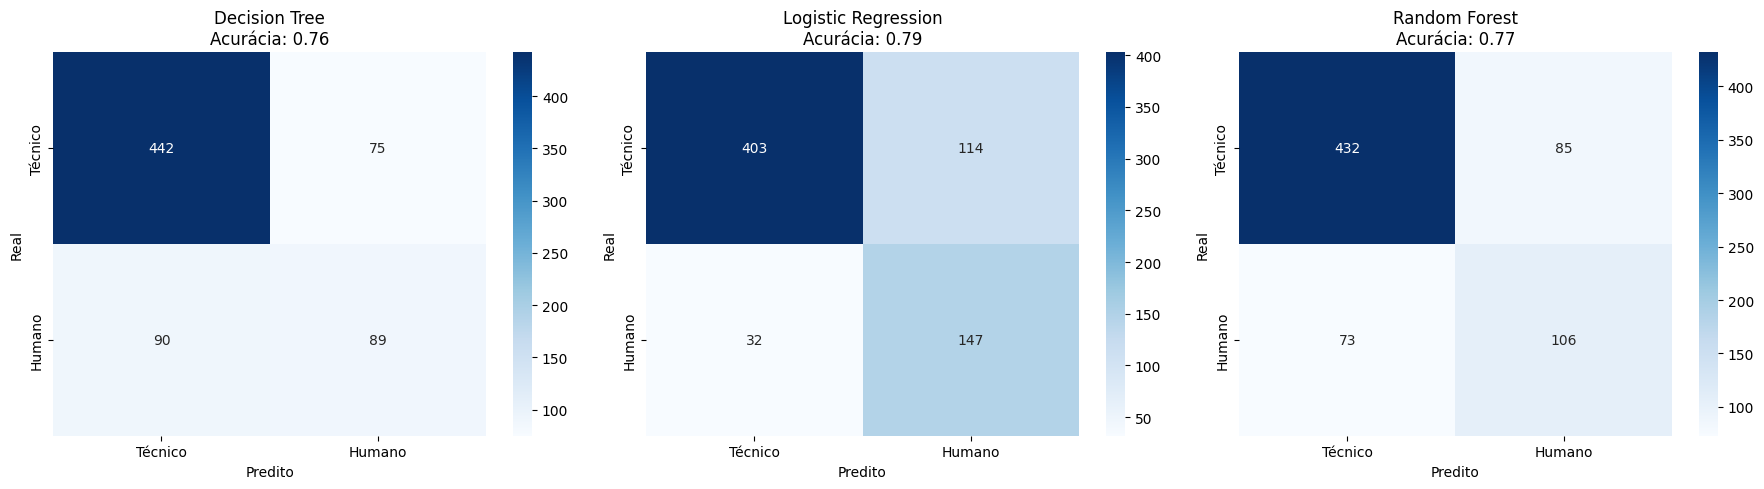

In [40]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
accuracies = {}

for ax, (name, model) in zip(axes, trained_models.items()):
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    accuracies[name] = acc

    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(
        cm, annot=True, fmt="d", ax=ax, cmap="Blues",
        xticklabels=["Técnico", "Humano"],
        yticklabels=["Técnico", "Humano"]
    )
    ax.set_title(f"{name}\nAcurácia: {acc:.2f}")
    ax.set_xlabel("Predito")
    ax.set_ylabel("Real")

plt.tight_layout()
plt.show()

# Relatório de Classificação

In [22]:
for name, model in trained_models.items():
    y_pred = model.predict(X_test)
    print(f"{'='*50}")
    print(f"  {name}")
    print(f"{'='*50}")
    print(classification_report(y_test, y_pred, target_names=["Técnico", "Humano"]))

  Decision Tree
              precision    recall  f1-score   support

     Técnico       0.83      0.85      0.84       517
      Humano       0.54      0.50      0.52       179

    accuracy                           0.76       696
   macro avg       0.69      0.68      0.68       696
weighted avg       0.76      0.76      0.76       696

  Logistic Regression
              precision    recall  f1-score   support

     Técnico       0.93      0.78      0.85       517
      Humano       0.56      0.82      0.67       179

    accuracy                           0.79       696
   macro avg       0.74      0.80      0.76       696
weighted avg       0.83      0.79      0.80       696

  Random Forest
              precision    recall  f1-score   support

     Técnico       0.86      0.84      0.85       517
      Humano       0.55      0.59      0.57       179

    accuracy                           0.77       696
   macro avg       0.71      0.71      0.71       696
weighted avg       0